<a href="https://colab.research.google.com/github/yusei0912-coder/EMG-FORCE-PROJECT-KINE425-CSUSM/blob/main/notebooks/EMG_Force_KINE425_Part01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

import data to drive

### Google Drive Mount and File Check (Colab)

This code mounts Google Drive to the Colab environment so files can be accessed locally. It then defines a directory path and uses the `os` module to list all files in that folder, confirming that the data is available and the path is correct.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
data_directory = '/content/drive/MyDrive/Colab Files/'

# List files in the specified directory to verify data is accessible
print(f"Listing files in '{data_directory}':")
for f in os.listdir(data_directory):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Listing files in '/content/drive/MyDrive/Colab Files/':
Part01_t02_EMG.txt
Part01_t03_EMG.txt
Part01_t04_EMG.txt
Part01_t01_Force.txt
Part01_t02_Force.txt
Part01_t03_Force.txt
Part01_t04_Force.txt
Part01_t01_EMG.txt
out


ai generated force and emg analysis

### EMG and Force Analysis (Part 01)

This script loads EMG and force data from multiple trials, processes the EMG by rectifying and smoothing it into an envelope, creates time axes based on sampling rates, and performs linear regression to predict force from EMG. It also downsamples EMG to match force data and visualizes both raw and predicted signals across trials.

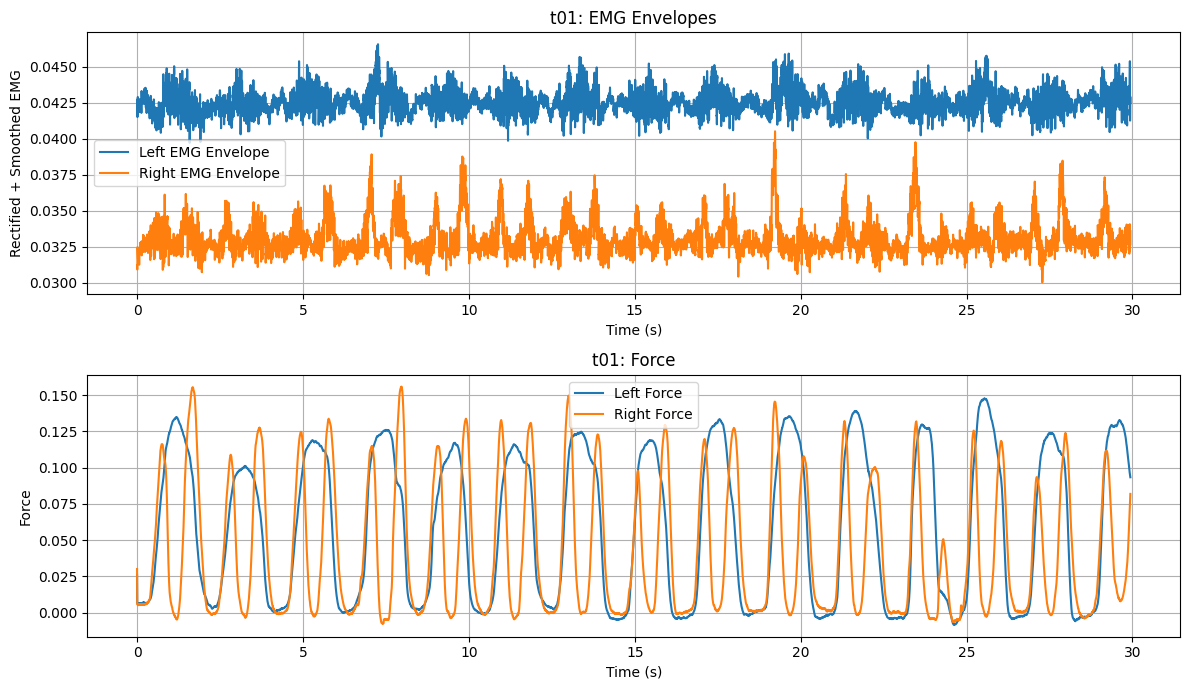

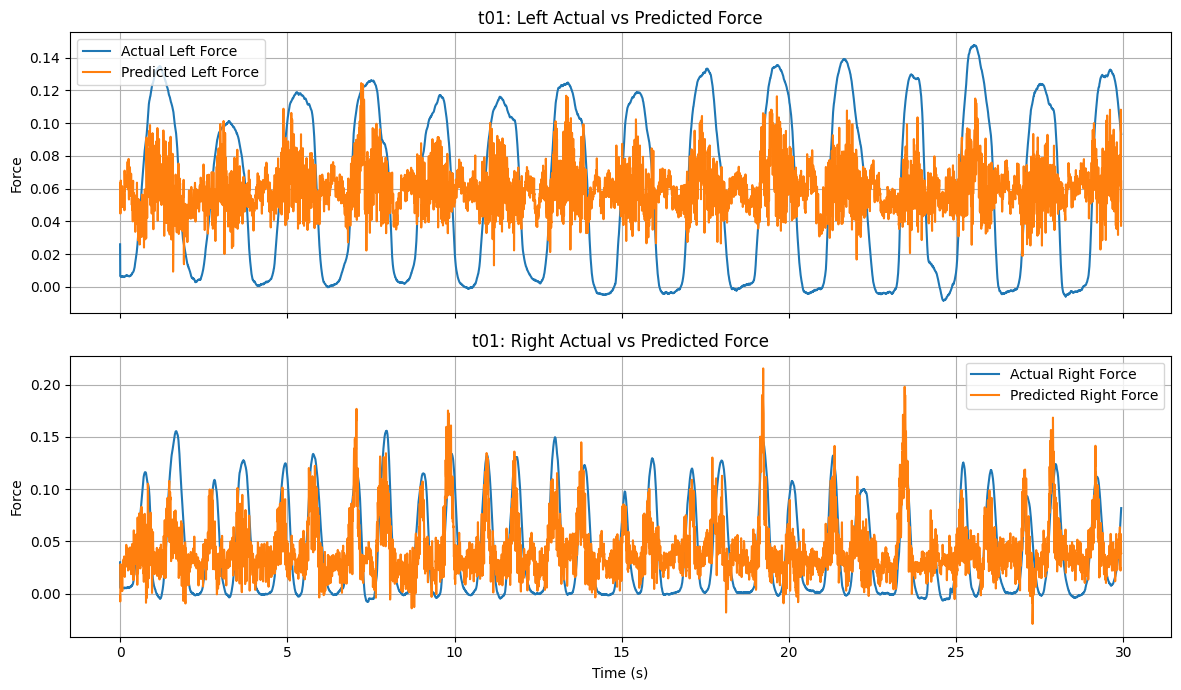

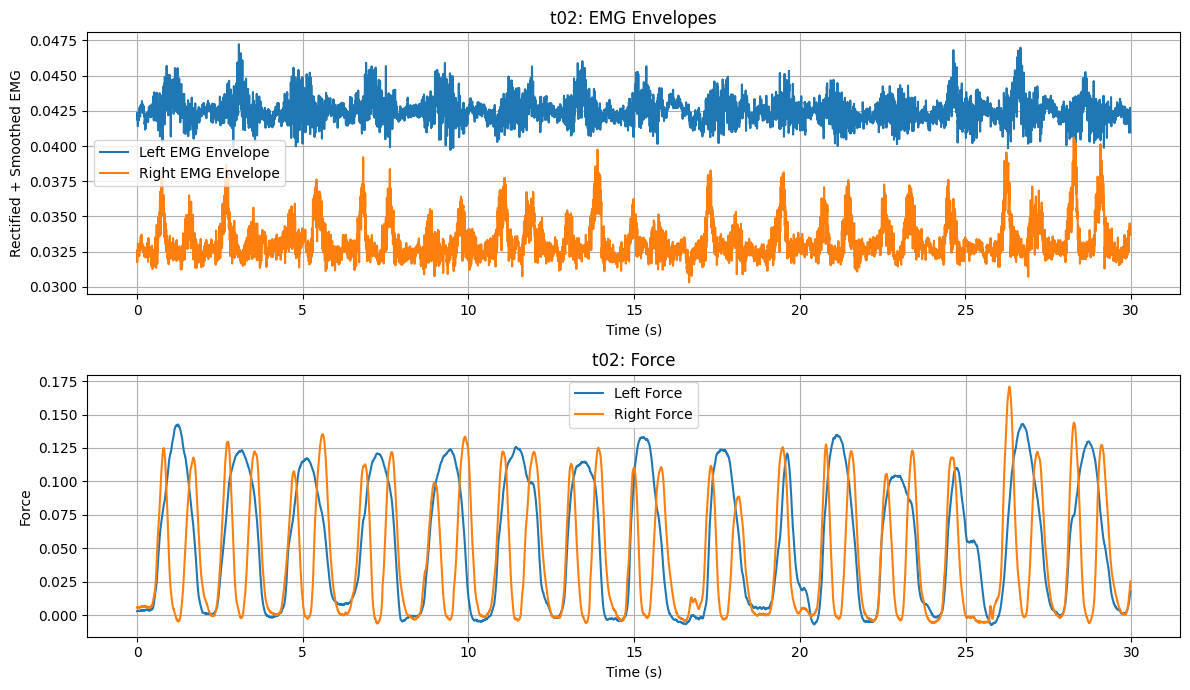

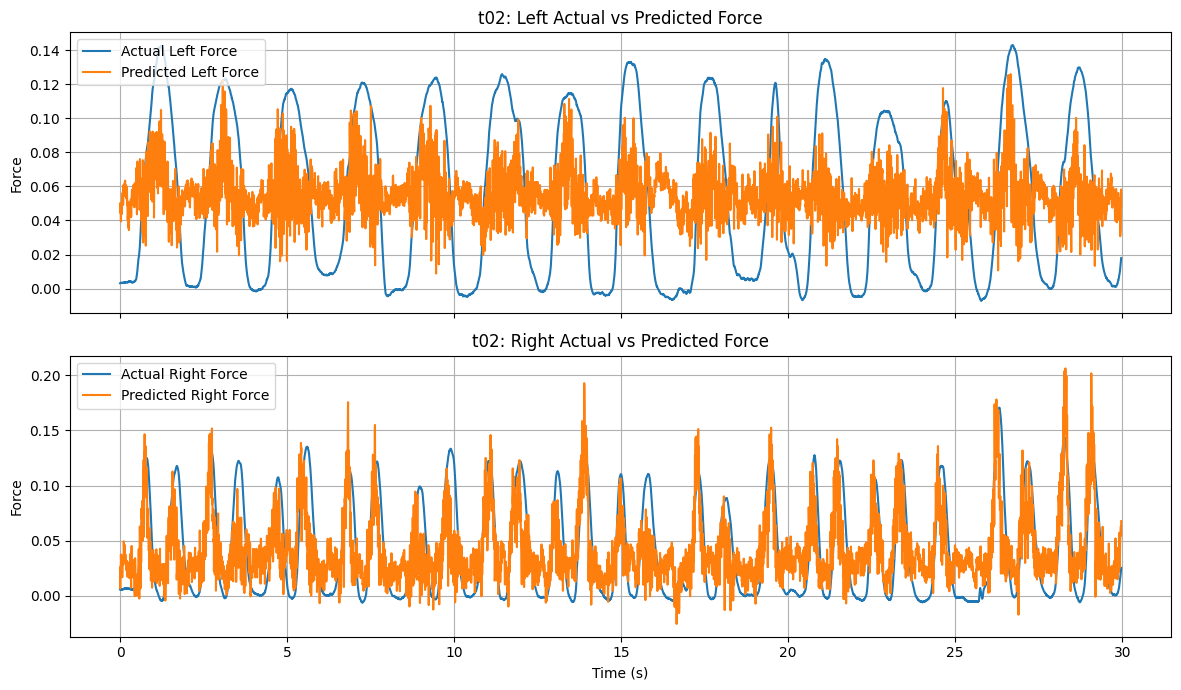

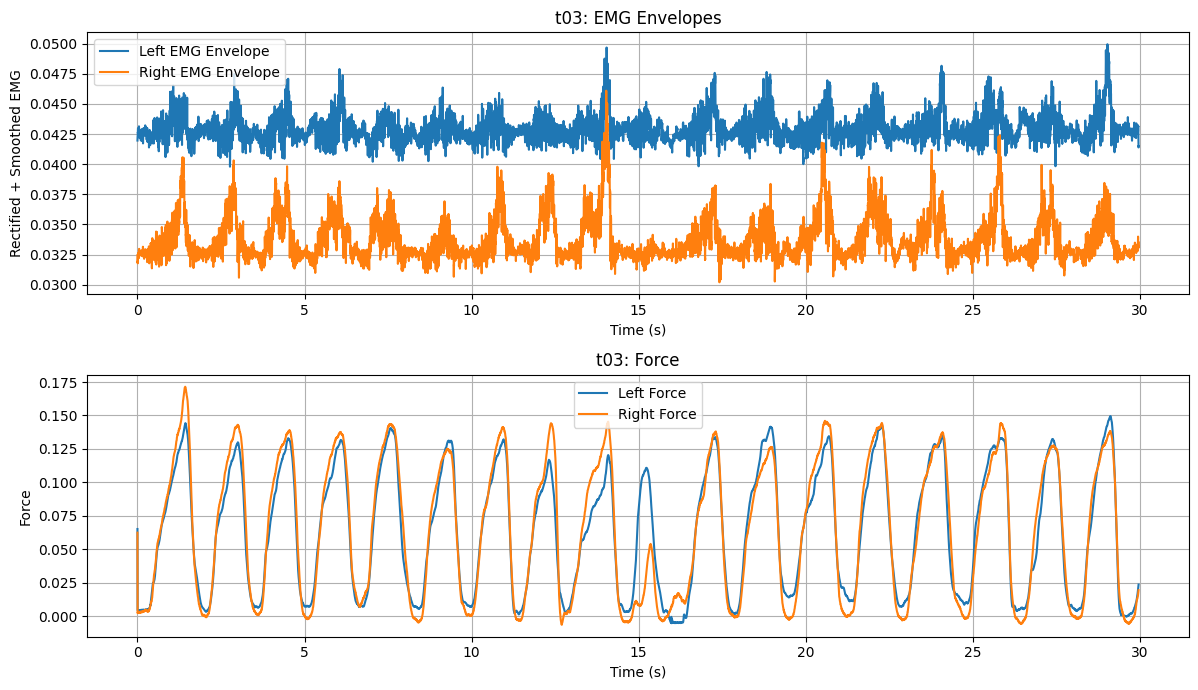

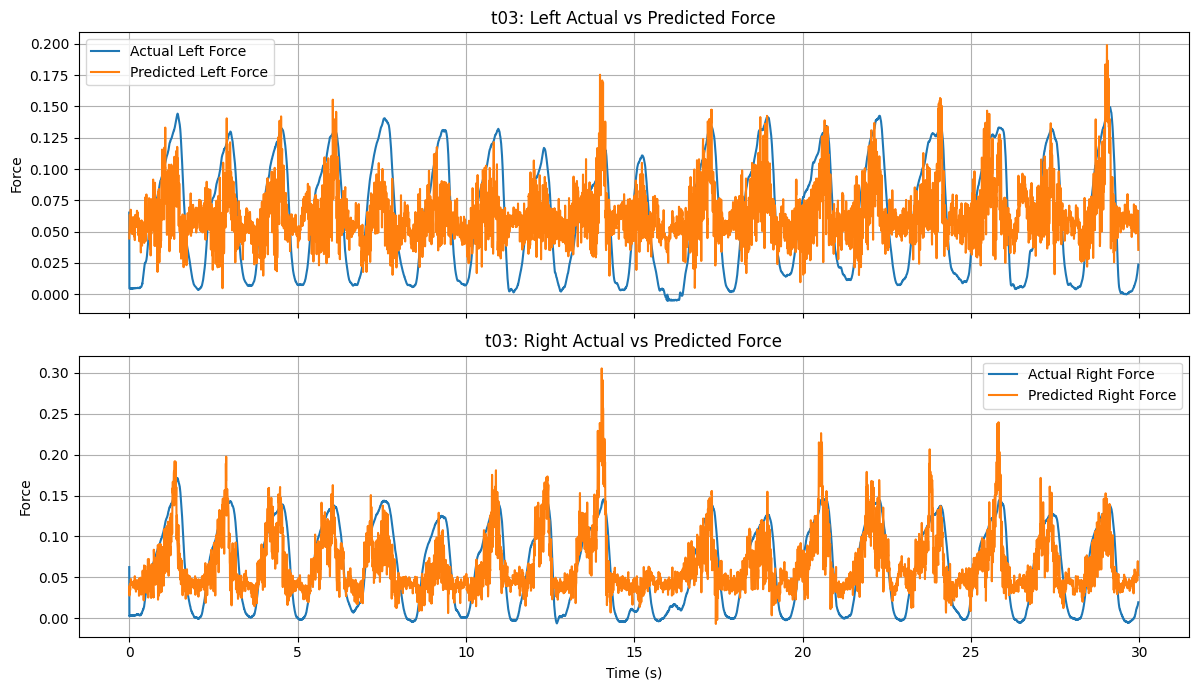

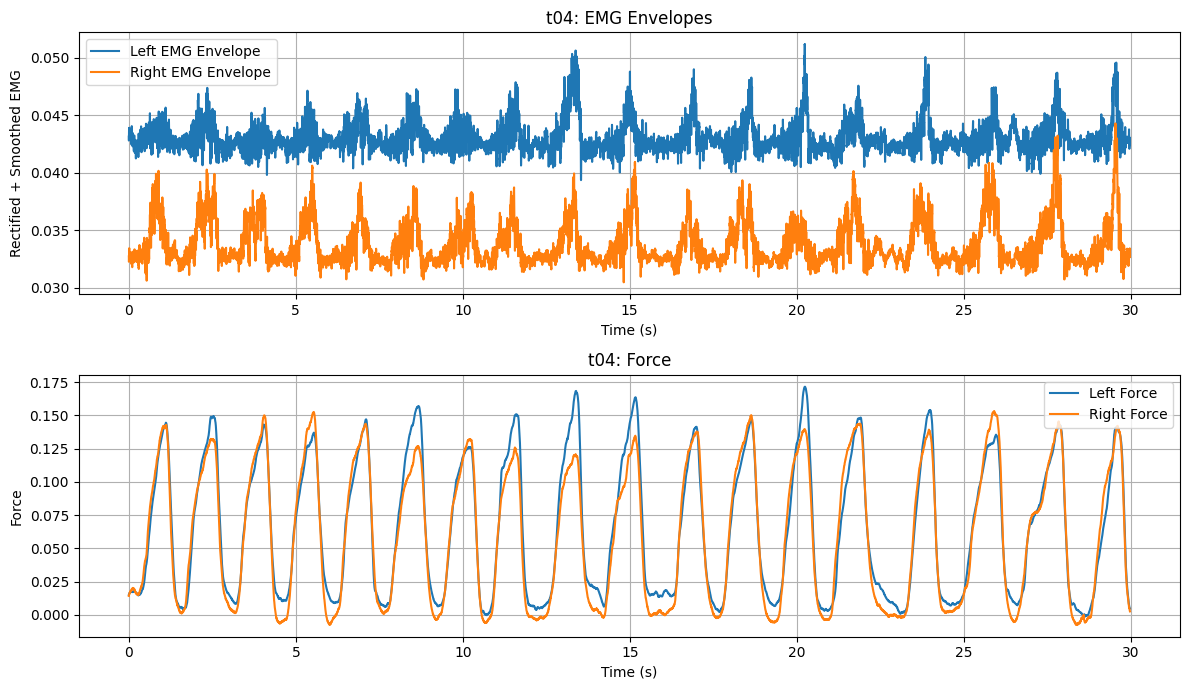

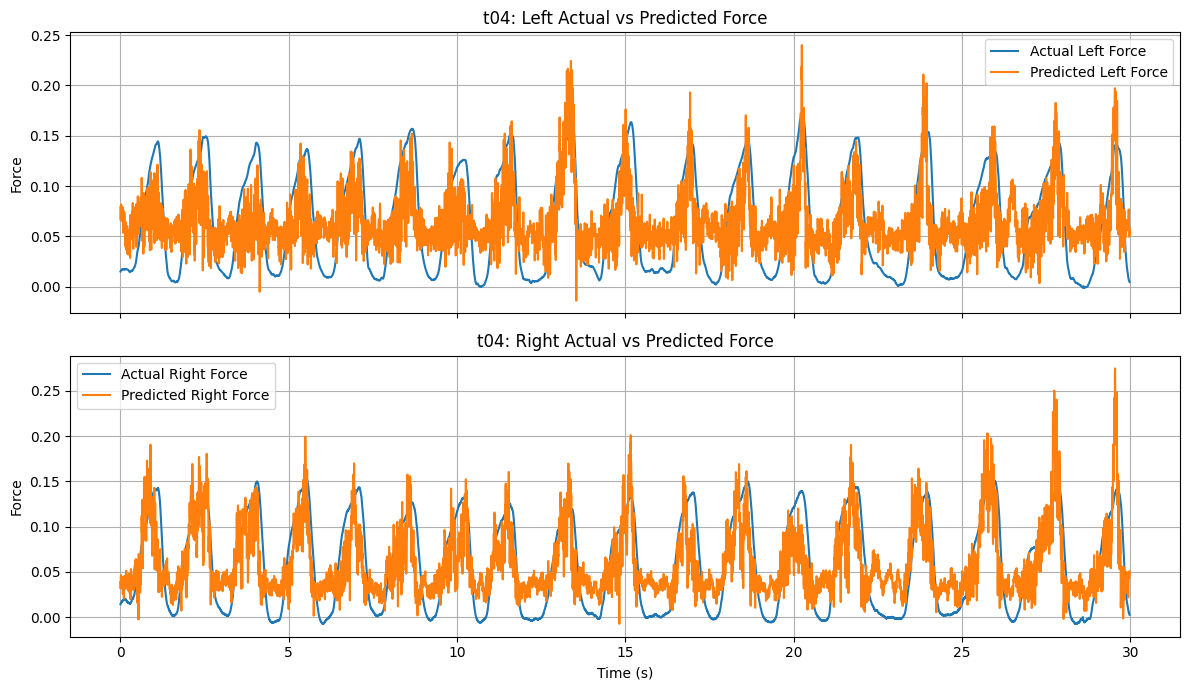

,Trial,Hand,Intercept,Slope,R^2
0,t01,Left,-0.706007,18.012570,0.067930
1,t01,Right,-0.731477,23.390675,0.332046
2,t02,Left,-0.647299,16.517235,0.073695
3,t02,Right,-0.731165,23.250745,0.441101
4,t03,Left,-0.772426,19.467140,0.206953
5,t03,Right,-0.617682,20.222681,0.467110
6,t04,Left,-0.864393,21.589099,0.309298
7,t04,Right,-0.630386,20.447167,0.528560


In [ ]:
# EMG and Force Analysis for KINE 425 - Part 01

# 0) Install/load needed libraries
# If needed, uncomment and run this line:
# !pip install pandas numpy matplotlib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sampling rates
FS_EMG = 1000   # Hz
FS_FORCE = 200  # Hz

# Moving average window for EMG envelope
# Requested range: 100-150 ms. Using 125 ms.
EMG_SMOOTH_MS = 125
EMG_WINDOW = int(FS_EMG * EMG_SMOOTH_MS / 1000)

trials = ["t01", "t02", "t03", "t04"]

all_data = {}
regression_results = []

for trial in trials:
    # 1) Read the tab-separated text files into data frames
    emg_file = f"{data_directory}Part01_{trial}_EMG.txt"
    force_file = f"{data_directory}Part01_{trial}_Force.txt"

    emg = pd.read_csv(emg_file, sep="\t")
    force = pd.read_csv(force_file, sep="\t")

    # 2) Build correct time axes using each signal's sampling rate
    emg["Time"] = np.arange(len(emg)) / FS_EMG
    force["Time"] = np.arange(len(force)) / FS_FORCE

    # 3) Rectify and smooth the EMG to create an EMG envelope
    emg["EMG Left Rectified"] = emg["EMG Left"].abs()
    emg["EMG Right Rectified"] = emg["EMG Right"].abs()

    emg["EMG Left Envelope"] = (
        emg["EMG Left Rectified"]
        .rolling(window=EMG_WINDOW, center=True, min_periods=1)
        .mean()
    )

    emg["EMG Right Envelope"] = (
        emg["EMG Right Rectified"]
        .rolling(window=EMG_WINDOW, center=True, min_periods=1)
        .mean()
    )

    all_data[trial] = {
        "emg": emg,
        "force": force
    }

    # 4) Plot Left and Right EMG envelopes and Forces vs Time
    fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

    axs[0].plot(emg["Time"], emg["EMG Left Envelope"], label="Left EMG Envelope")
    axs[0].plot(emg["Time"], emg["EMG Right Envelope"], label="Right EMG Envelope")
    axs[0].set_title(f"{trial}: EMG Envelopes")
    axs[0].set_xlabel("Time (s)")
    axs[0].set_ylabel("Rectified + Smoothed EMG")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(force["Time"], force["Raw Force Left"], label="Left Force")
    axs[1].plot(force["Time"], force["Raw Force Right"], label="Right Force")
    axs[1].set_title(f"{trial}: Force")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Force")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # 5) Downsample EMG envelope from 1000 Hz to 200 Hz
    # 1000 / 200 = 5, so keep every 5th EMG sample.
    emg_down = emg.iloc[::5].reset_index(drop=True)

    # Match lengths in case one vector is slightly longer than the other
    n = min(len(emg_down), len(force))
    emg_down = emg_down.iloc[:n].copy()
    force_matched = force.iloc[:n].copy()

    # 6) Fit simple linear regressions: Force ~ EMG, for each hand
    for hand in ["Left", "Right"]:
        X = emg_down[[f"EMG {hand} Envelope"]].values
        y = force_matched[f"Raw Force {hand}"].values

        slope, intercept = np.polyfit(X.ravel(), y, 1)
        predicted_force = intercept + slope * X.ravel()
        force_matched[f"Predicted Force {hand}"] = predicted_force

        ss_res = np.sum((y - predicted_force) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        regression_results.append({
            "Trial": trial,
            "Hand": hand,
            "Intercept": intercept,
            "Slope": slope,
            "R^2": r_squared
        })

    all_data[trial]["emg_downsampled"] = emg_down
    all_data[trial]["force_matched"] = force_matched

    # 7) Plot predicted force from EMG alongside actual force over time
    fig, axs = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

    axs[0].plot(force_matched["Time"], force_matched["Raw Force Left"], label="Actual Left Force")
    axs[0].plot(force_matched["Time"], force_matched["Predicted Force Left"], label="Predicted Left Force")
    axs[0].set_title(f"{trial}: Left Actual vs Predicted Force")
    axs[0].set_ylabel("Force")
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(force_matched["Time"], force_matched["Raw Force Right"], label="Actual Right Force")
    axs[1].plot(force_matched["Time"], force_matched["Predicted Force Right"], label="Predicted Right Force")
    axs[1].set_title(f"{trial}: Right Actual vs Predicted Force")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Force")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Display regression summary table
regression_df = pd.DataFrame(regression_results)
regression_df

have ai generate 2 raw emg and force plots

### EMG and Force Export to Excel (Part 02)

This script reads EMG and force data for a selected trial, generates time vectors, and exports both datasets into Excel files with embedded plots. It ensures an output directory exists, checks if files already exist to avoid overwriting, and saves both raw data and visualizations using `xlsxwriter`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Install xlsxwriter if not already installed
# This is necessary for pandas to write .xlsx files with images
!pip install xlsxwriter

# Ensure the output directory exists
output_dir = os.path.join(data_directory, "out")
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory '{output_dir}' ensured.")

# Define the trial for which to generate the Excel files
trial = "t01"

# Construct file paths for both EMG and Force for the specified trial
emg_file_path = os.path.join(data_directory, f"Part01_{trial}_EMG.txt")
force_file_path = os.path.join(data_directory, f"Part01_{trial}_Force.txt")

# 1) Read the tab-separated text files into data frames
try:
    emg = pd.read_csv(emg_file_path, sep="\t")
    force = pd.read_csv(force_file_path, sep="\t")
    print(f"Successfully read EMG data from '{emg_file_path}'")
    print(f"Successfully read Force data from '{force_file_path}'")
except FileNotFoundError as e:
    print(f"Error reading file: {e}. Please ensure the file exists in the specified path.")
    # Exit or handle the error appropriately if the file is critical
    exit()

# 2) Build correct time axes using each signal's sampling rate
# FS_EMG and FS_FORCE are expected to be available from previous cells' execution
emg["Time"] = np.arange(len(emg)) / FS_EMG
force["Time"] = np.arange(len(force)) / FS_FORCE

# --- Determine if Excel files already exist ---
emg_output_excel_path = os.path.join(output_dir, f"Part01_{trial}_Raw_EMG_Analysis.xlsx")
force_output_excel_path = os.path.join(output_dir, f"Part01_{trial}_Raw_Force_Analysis.xlsx")

# If either Excel file exists, we skip all output for this trial.
skip_output_for_trial = os.path.exists(emg_output_excel_path) or os.path.exists(force_output_excel_path)

if not skip_output_for_trial:
    # --- Generate and save Raw EMG plot ---
    fig_emg, ax_emg = plt.subplots(figsize=(12, 6))
    ax_emg.plot(emg["Time"], emg["EMG Left"], label="Raw EMG Left")
    ax_emg.plot(emg["Time"], emg["EMG Right"], label="Raw EMG Right")
    ax_emg.set_title(f"{trial}: Raw EMG Data")
    ax_emg.set_xlabel("Time (s)")
    ax_emg.set_ylabel("EMG Amplitude")
    ax_emg.legend()
    ax_emg.grid(True)
    emg_plot_filename = f"Part01_{trial}_Raw_EMG_Plot.png"
    emg_plot_path = os.path.join(output_dir, emg_plot_filename)
    plt.savefig(emg_plot_path)
    plt.close(fig_emg) # Close the plot to prevent it from displaying in the notebook
    print(f"Raw EMG plot saved to '{emg_plot_path}'")

    # --- Generate and save Raw Force plot ---
    fig_force, ax_force = plt.subplots(figsize=(12, 6))
    ax_force.plot(force["Time"], force["Raw Force Left"], label="Raw Force Left")
    ax_force.plot(force["Time"], force["Raw Force Right"], label="Raw Force Right")
    ax_force.set_title(f"{trial}: Raw Force Data")
    ax_force.set_xlabel("Time (s)")
    ax_force.set_ylabel("Force")
    ax_force.legend()
    ax_force.grid(True)
    force_plot_filename = f"Part01_{trial}_Raw_Force_Plot.png"
    force_plot_path = os.path.join(output_dir, force_plot_filename)
    plt.savefig(force_plot_path)
    plt.close(fig_force) # Close the plot
    print(f"Raw Force plot saved to '{force_plot_path}'")

    # --- Write EMG data and embed plot into an Excel file ---
    try:
        with pd.ExcelWriter(emg_output_excel_path, engine='xlsxwriter') as writer:
            # Write EMG data to a sheet
            emg.to_excel(writer, sheet_name='Raw EMG Data', index=False)
            # Embed EMG plot on the same sheet, to the right of the data
            worksheet_emg_data = writer.sheets['Raw EMG Data']
            # Insert image after data columns + a few for spacing
            worksheet_emg_data.insert_image(0, emg.shape[1] + 2, emg_plot_path)

        print(f"Excel file successfully created at '{emg_output_excel_path}' with raw EMG data and plot.")
    except Exception as e:
        print(f"Error creating EMG Excel file: {e}")

    # --- Write Force data and embed plot into an Excel file ---
    try:
        with pd.ExcelWriter(force_output_excel_path, engine='xlsxwriter') as writer:
            # Write Force data to a sheet
            force.to_excel(writer, sheet_name='Raw Force Data', index=False)
            # Embed Force plot on the same sheet, to the right of the data
            worksheet_force_data = writer.sheets['Raw Force Data']
            # Insert image after data columns + a few for spacing
            worksheet_force_data.insert_image(0, force.shape[1] + 2, force_plot_path)

        print(f"Excel file successfully created at '{force_output_excel_path}' with raw Force data and plot.")
    except Exception as e:
        print(f"Error creating Force Excel file: {e}")

Output directory '/content/drive/MyDrive/Colab Files/out' ensured.
Successfully read EMG data from '/content/drive/MyDrive/Colab Files/Part01_t01_EMG.txt'
Successfully read Force data from '/content/drive/MyDrive/Colab Files/Part01_t01_Force.txt'


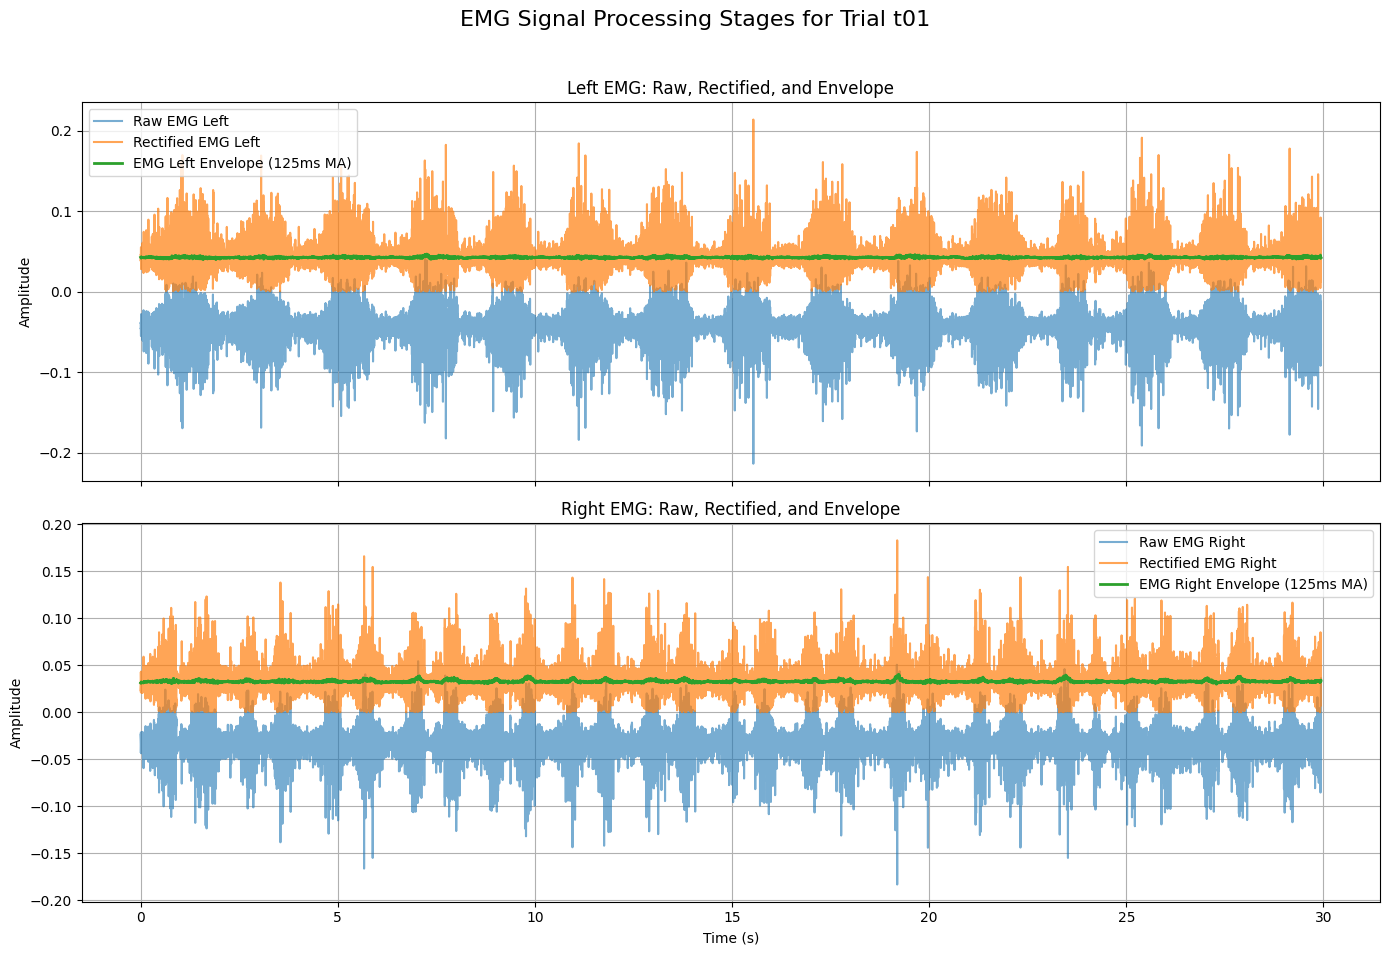

In [ ]:
import matplotlib.pyplot as plt

# Select a trial to display the output for, for example 't01'
trial_to_display = "t01"

# Retrieve the EMG data for the selected trial from the 'all_data' dictionary
# 'all_data' is expected to be populated by the execution of a previous cell (e.g., ee9ac2ae)
if 'all_data' in locals() and trial_to_display in all_data:
    emg_data = all_data[trial_to_display]['emg']

    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"EMG Signal Processing Stages for Trial {trial_to_display}", fontsize=16)

    # Plot for Left EMG
    axs[0].plot(emg_data["Time"], emg_data["EMG Left"], label="Raw EMG Left", alpha=0.6)
    axs[0].plot(emg_data["Time"], emg_data["EMG Left Rectified"], label="Rectified EMG Left", alpha=0.7)
    axs[0].plot(emg_data["Time"], emg_data["EMG Left Envelope"], label="EMG Left Envelope (125ms MA)", linewidth=2)
    axs[0].set_title("Left EMG: Raw, Rectified, and Envelope")
    axs[0].set_ylabel("Amplitude")
    axs[0].legend()
    axs[0].grid(True)

    # Plot for Right EMG
    axs[1].plot(emg_data["Time"], emg_data["EMG Right"], label="Raw EMG Right", alpha=0.6)
    axs[1].plot(emg_data["Time"], emg_data["EMG Right Rectified"], label="Rectified EMG Right", alpha=0.7)
    axs[1].plot(emg_data["Time"], emg_data["EMG Right Envelope"], label="EMG Right Envelope (125ms MA)", linewidth=2)
    axs[1].set_title("Right EMG: Raw, Rectified, and Envelope")
    axs[1].set_xlabel("Time (s)")
    axs[1].set_ylabel("Amplitude")
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print("Error: 'all_data' dictionary not found or specified trial not in data. Please run previous cells.")

Made ai generate me "The raw EMG signal oscillates above and below zero. Bursts of larger oscillations correspond to periods
of muscle activity; quieter stretches correspond to rest.
Compute |EMG|, then apply a 100–150 ms moving average."

### EMG Signal Visualization and Export (Part 03)

This script visualizes different stages of EMG processing (raw, rectified, and envelope) for a selected trial, then reloads EMG and force data to generate time vectors and export both datasets into Excel files with embedded plots. It uses a previously created `all_data` dictionary for visualization and ensures outputs are only generated if they do not already exist.


--- Analysis for Trial t01 ---


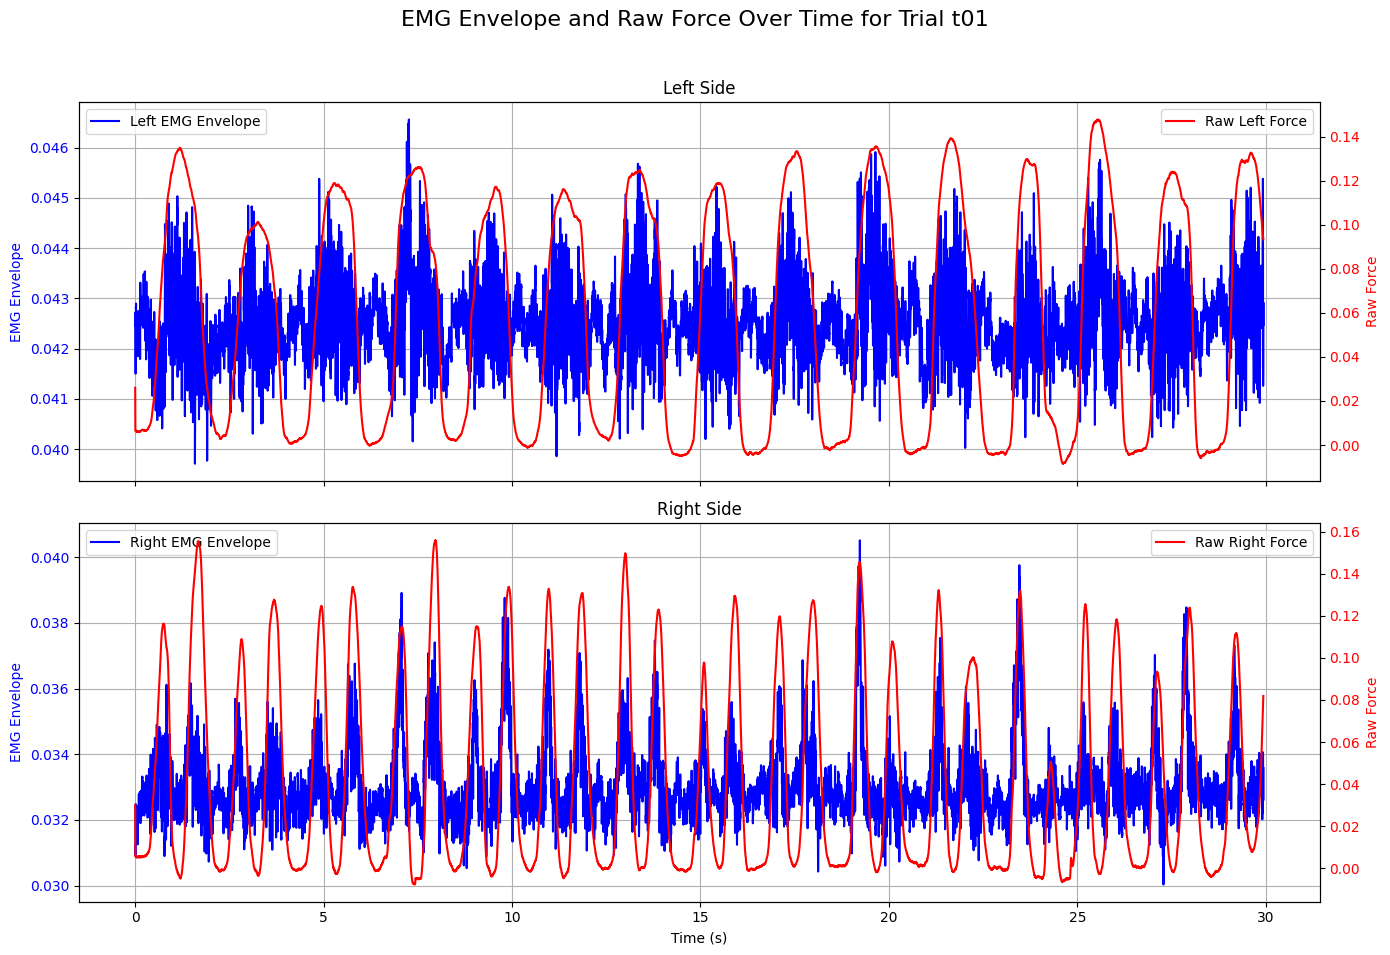


Left Side Regression Results:
  Slope: 18.0126
  Intercept: -0.7060
  R^2: 0.0679

Right Side Regression Results:
  Slope: 23.3907
  Intercept: -0.7315
  R^2: 0.3320


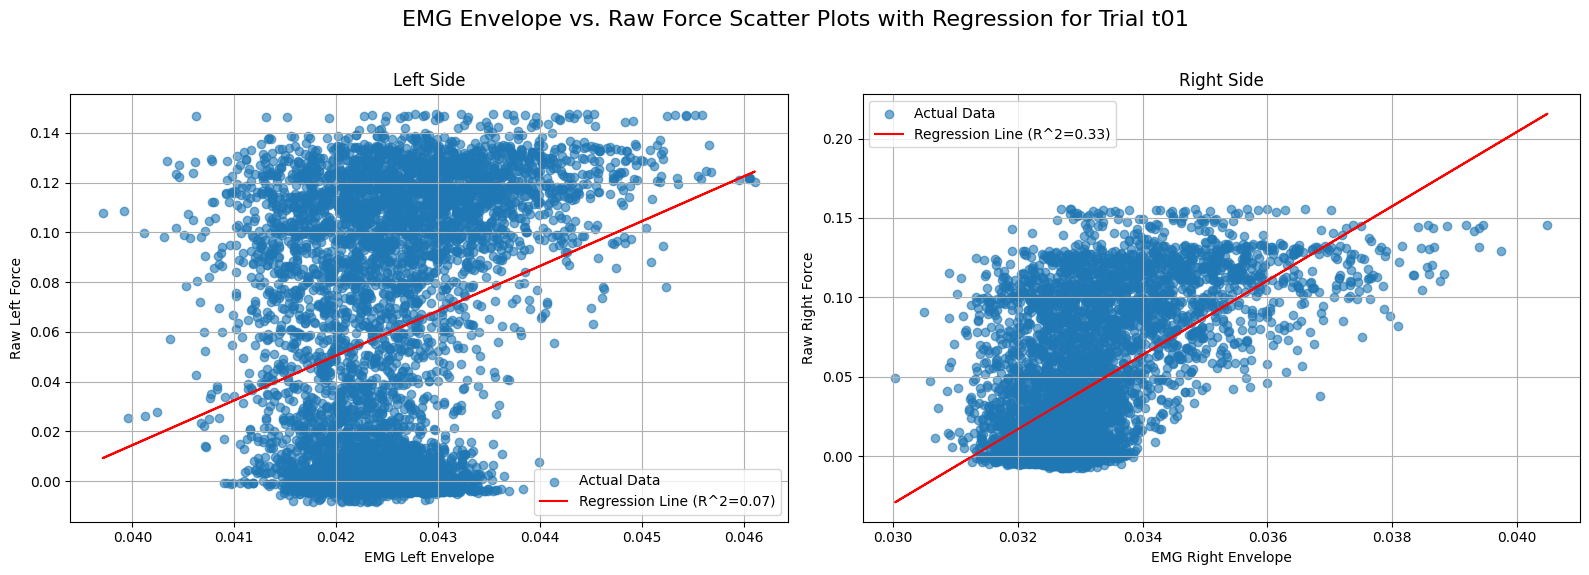

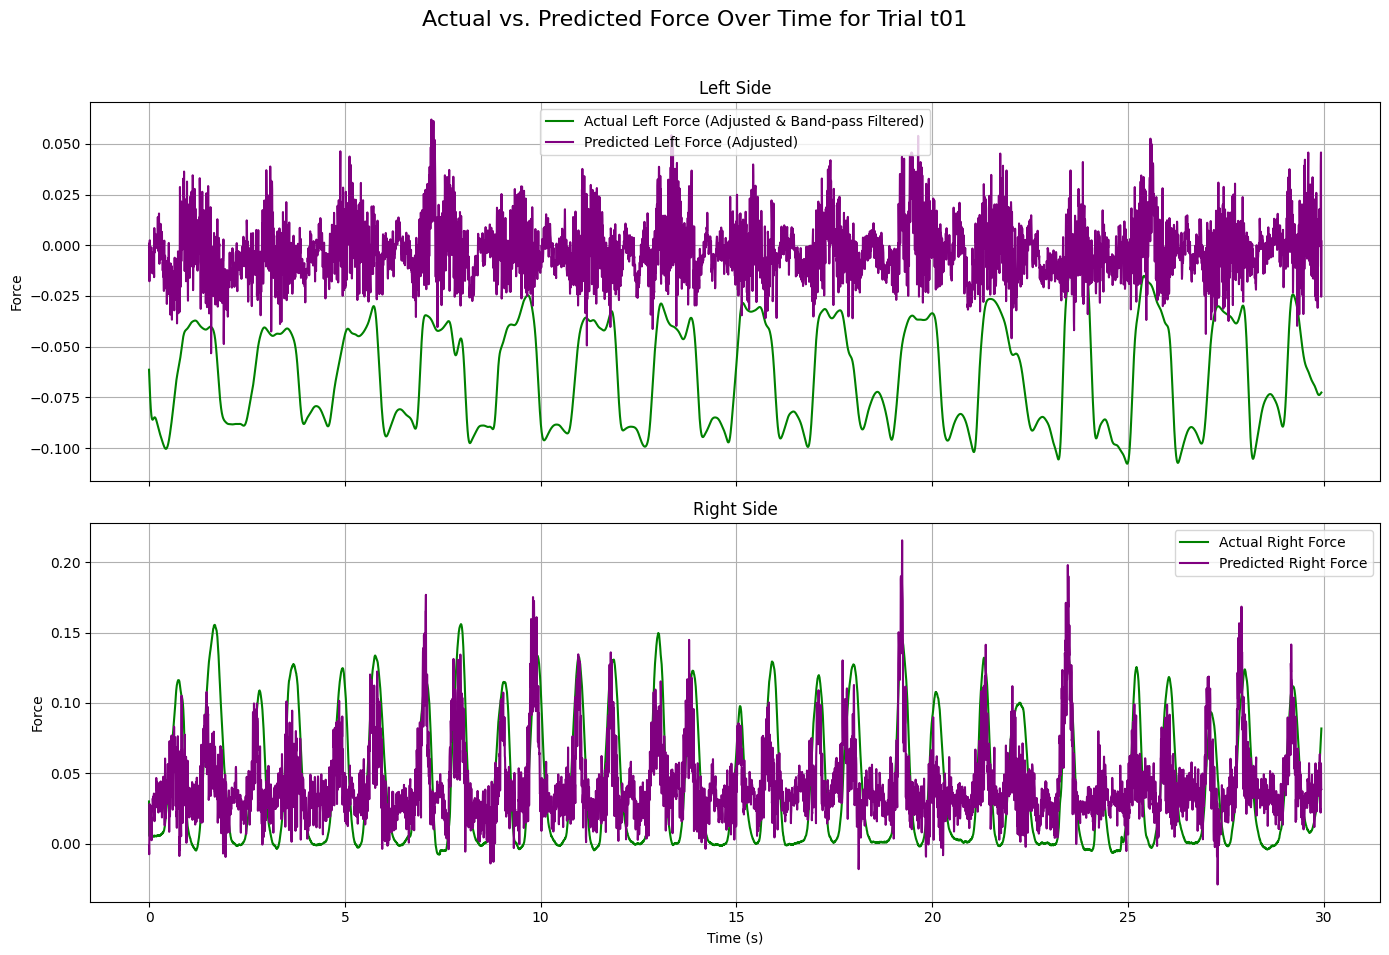

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal # Import scipy.signal for filtering

# Ensure these are defined, assuming previous cells have been run.
# If not, please run cell ee9ac2ae first to set up FS_EMG, FS_FORCE, EMG_WINDOW, and all_data.
FS_EMG = 1000   # Hz
FS_FORCE = 200  # Hz
EMG_SMOOTH_MS = 125 # ms
EMG_WINDOW = int(FS_EMG * EMG_SMOOTH_MS / 1000)

trial = "t01" # Example trial

if 'all_data' not in locals() or trial not in all_data:
    print("Error: 'all_data' dictionary not found or specified trial not in data. Please run cell ee9ac2ae.")
else:
    emg = all_data[trial]['emg']
    force = all_data[trial]['force']

    print(f"\n--- Analysis for Trial {trial} ---")

    # Plot EMG envelope and force over time on the same graph for both left and right sides using two y-axes
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig.suptitle(f"EMG Envelope and Raw Force Over Time for Trial {trial}", fontsize=16)

    # Left side plot
    ax1_left = axs[0]
    ax1_left.plot(emg["Time"], emg["EMG Left Envelope"], label="Left EMG Envelope", color='blue')
    ax1_left.set_ylabel("EMG Envelope", color='blue')
    ax1_left.tick_params(axis='y', labelcolor='blue')
    ax1_left.legend(loc='upper left')
    ax1_left.grid(True)

    ax2_left = ax1_left.twinx()  # Create a second y-axis that shares the same x-axis
    ax2_left.plot(force["Time"], force["Raw Force Left"], label="Raw Left Force", color='red', linestyle='-')
    ax2_left.set_ylabel("Raw Force", color='red')
    ax2_left.tick_params(axis='y', labelcolor='red')
    ax2_left.legend(loc='upper right')
    axs[0].set_title("Left Side")

    # Right side plot
    ax1_right = axs[1]
    ax1_right.plot(emg["Time"], emg["EMG Right Envelope"], label="Right EMG Envelope", color='blue')
    ax1_right.set_ylabel("EMG Envelope", color='blue')
    ax1_right.tick_params(axis='y', labelcolor='blue')
    ax1_right.legend(loc='upper left')
    ax1_right.grid(True)

    ax2_right = ax1_right.twinx()  # Create a second y-axis that shares the same x-axis
    ax2_right.plot(force["Time"], force["Raw Force Right"], label="Raw Right Force", color='red', linestyle='-')
    ax2_right.set_ylabel("Raw Force", color='red')
    ax2_right.tick_params(axis='y', labelcolor='red')
    ax2_right.legend(loc='upper right')
    axs[1].set_title("Right Side")

    axs[1].set_xlabel("Time (s)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout to prevent suptitle overlap
    plt.show()

    # Downsample EMG envelope from 1000 Hz to 200 Hz (every 5th sample)
    emg_down = emg.iloc[::5].reset_index(drop=True)

    # Match lengths in case one vector is slightly longer than the other
    n = min(len(emg_down), len(force))
    emg_down = emg_down.iloc[:n].copy()
    force_matched = force.iloc[:n].copy()

    # Create scatter plots of EMG vs force for both left and right sides
    # Fit linear regression models, and print slope, intercept, and R^2 values
    fig_scatter, axs_scatter = plt.subplots(1, 2, figsize=(16, 6))
    fig_scatter.suptitle(f"EMG Envelope vs. Raw Force Scatter Plots with Regression for Trial {trial}", fontsize=16)

    for i, hand in enumerate(["Left", "Right"]):
        X = emg_down[[f"EMG {hand} Envelope"]].values
        y = force_matched[f"Raw Force {hand}"].values

        # Fit linear regression model
        slope, intercept = np.polyfit(X.ravel(), y, 1)
        predicted_force_scatter = intercept + slope * X.ravel()

        # Calculate R^2
        ss_res = np.sum((y - predicted_force_scatter) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        r_squared = 1 - (ss_res / ss_tot)

        # Print regression parameters
        print(f"\n{hand} Side Regression Results:")
        print(f"  Slope: {slope:.4f}")
        print(f"  Intercept: {intercept:.4f}")
        print(f"  R^2: {r_squared:.4f}")

        # Scatter plot
        axs_scatter[i].scatter(X, y, alpha=0.6, label="Actual Data")
        axs_scatter[i].plot(X, predicted_force_scatter, color='red', label=f"Regression Line (R^2={r_squared:.2f})")
        axs_scatter[i].set_title(f"{hand} Side")
        axs_scatter[i].set_xlabel(f"EMG {hand} Envelope")
        axs_scatter[i].set_ylabel(f"Raw {hand} Force")
        axs_scatter[i].legend()
        axs_scatter[i].grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout
    plt.show()

    # Plot predicted force alongside actual force over time
    fig_pred, axs_pred = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    fig_pred.suptitle(f"Actual vs. Predicted Force Over Time for Trial {trial}", fontsize=16)

    # Filter parameters for force data
    CUTOFF_FREQ_LOWPASS = 6 # Hz (e.g., 6 Hz for force data)
    CUTOFF_FREQ_HIGHPASS = 0.5 # Hz for removing baseline drift
    FILTER_ORDER = 4 # Order of the Butterworth filter
    nyq = 0.5 * FS_FORCE # Nyquist frequency

    # Low-pass filter coefficients
    normal_cutoff_lowpass = CUTOFF_FREQ_LOWPASS / nyq
    b_lowpass, a_lowpass = signal.butter(FILTER_ORDER, normal_cutoff_lowpass, btype='low', analog=False)

    # High-pass filter coefficients
    normal_cutoff_highpass = CUTOFF_FREQ_HIGHPASS / nyq
    b_highpass, a_highpass = signal.butter(FILTER_ORDER, normal_cutoff_highpass, btype='high', analog=False)


    for i, hand in enumerate(["Left", "Right"]):
        X = emg_down[[f"EMG {hand} Envelope"]].values
        y = force_matched[f"Raw Force {hand}"].values

        slope, intercept = np.polyfit(X.ravel(), y, 1)
        predicted_force_time = intercept + slope * X.ravel()

        if hand == "Right":
            axs_pred[i].plot(force_matched["Time"], y, label=f"Actual {hand} Force", color='green')
            axs_pred[i].plot(force_matched["Time"], predicted_force_time, label=f"Predicted {hand} Force", color='purple', linestyle='-')
        else:
            # Apply Butterworth high-pass filter first
            y_highpass_filtered = signal.filtfilt(b_highpass, a_highpass, y)
            # Then apply Butterworth low-pass filter
            y_bandpass_filtered = signal.filtfilt(b_lowpass, a_lowpass, y_highpass_filtered)

            # Apply the subtraction for the Left side's actual and predicted force
            axs_pred[i].plot(force_matched["Time"], y_bandpass_filtered - 0.0625, label=f"Actual {hand} Force (Adjusted & Band-pass Filtered)", color='green')
            axs_pred[i].plot(force_matched["Time"], predicted_force_time - 0.0625, label=f"Predicted {hand} Force (Adjusted)", color='purple', linestyle='-')
        axs_pred[i].set_title(f"{hand} Side")
        axs_pred[i].set_ylabel("Force")
        axs_pred[i].legend()
        axs_pred[i].grid(True)

    axs_pred[1].set_xlabel("Time (s)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout
    plt.show()

Had ai develop me EMG envelope overlaid with force to Scatter plot and linear regression

### EMG–Force Relationship Analysis and Visualization (Part 04)

This script analyzes the relationship between EMG envelope and force for a selected trial. It plots EMG and force together over time using dual y-axes, performs linear regression between EMG and force, visualizes the relationship with scatter plots, and compares actual vs predicted force over time.

Key steps include downsampling EMG to match force sampling rate, fitting regression models for left and right sides, computing R² values, and generating multiple visualization types to evaluate signal relationships.